# Image Processing 1
### Stop seeing images, start seeing data

### The famous pipe. How people reproached me for it! And yet, could you stuff my pipe? No, it's just a representation, is it not? So if I had written on my picture "This is a pipe", I'd have been lying!
René Magritte

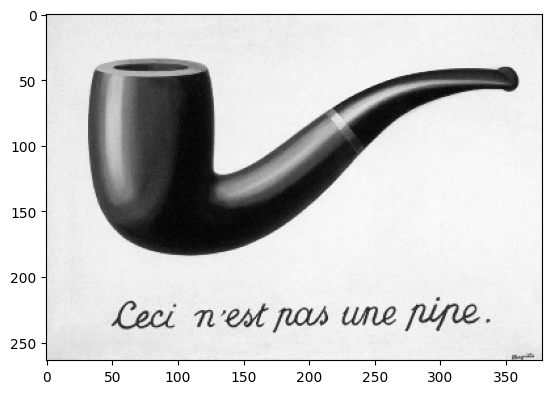

In [11]:
import requests
import numpy as np
import cv2
import matplotlib.pyplot as plt
url = "https://upload.wikimedia.org/wikipedia/en/b/b9/MagrittePipe.jpg"
response = requests.get(url,headers={"User-Agent": "Mozilla/5.0"},stream=True).raw
image = np.asarray(bytearray(response.read()), dtype="uint8")
image = cv2.imdecode(image, cv2.IMREAD_COLOR)
image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
plt.imshow(image,cmap="gray")

# Let's see what this "pipe" really is


In [16]:
image

array([[221, 222, 217, ..., 235, 238, 239],
       [214, 219, 218, ..., 230, 238, 238],
       [216, 223, 222, ..., 235, 236, 235],
       ...,
       [216, 218, 220, ..., 220, 219, 219],
       [220, 214, 213, ..., 229, 223, 223],
       [219, 215, 211, ..., 220, 225, 225]], shape=(264, 378), dtype=uint8)

Gasp, the image is… **data**.

A computer only displays pixels, you apply meaning to those pixels.

Here are the same pixels with random noise added

Text(0.5, 1.0, 'This is a jagged terrain map.. cant you see it?')

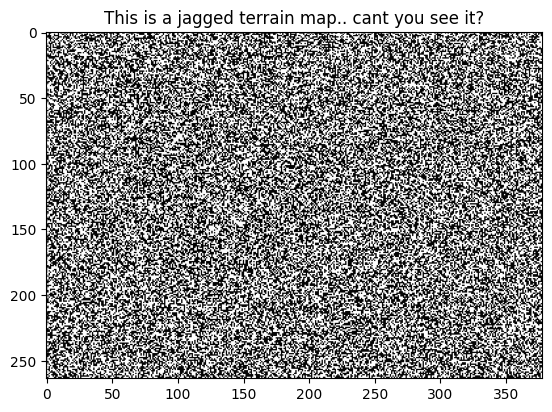

In [19]:

plt.imshow(
    np.where(
        np.random.randint(2, size=(image.shape))
    ,10000,0)+image,cmap='gray'
          )
plt.title("This is a jagged terrain map.. cant you see it?")

# Let's make an image from scratch to to build intuition

In [22]:
# make a 6x6 matrix of zeros
zeromatrix=np.zeros((6,6))
zeromatrix

array([[0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.]])

In [23]:
# make a 6x6 matrix of 255s
maxmatrix=np.zeros((6,6))+255
maxmatrix

array([[255., 255., 255., 255., 255., 255.],
       [255., 255., 255., 255., 255., 255.],
       [255., 255., 255., 255., 255., 255.],
       [255., 255., 255., 255., 255., 255.],
       [255., 255., 255., 255., 255., 255.],
       [255., 255., 255., 255., 255., 255.]])

In [24]:
#stack the matrices in a repeated pattern

cbimg=np.concatenate(
    [np.concatenate([zeromatrix,maxmatrix ,zeromatrix], axis=1),
    np.concatenate([maxmatrix,zeromatrix,maxmatrix], axis=1),
    np.concatenate([zeromatrix,maxmatrix ,zeromatrix], axis=1)],axis=0
    )

Bring your own meaning to the image and **Abra Kadabra** an image of **something**

Text(0.5, 1.0, 'This Is Not a Checkerboard\n')

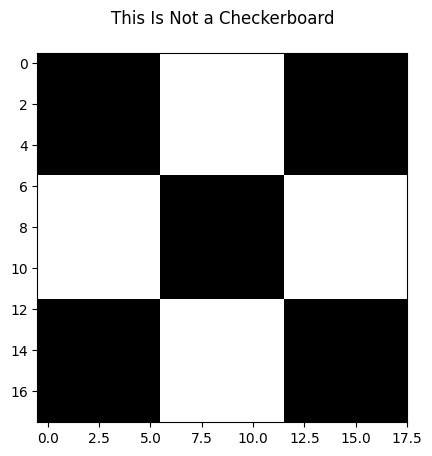

In [26]:


import matplotlib.pyplot as plt
plt.imshow(cbimg,cmap="gray")
plt.title("This Is Not a Checkerboard\n")


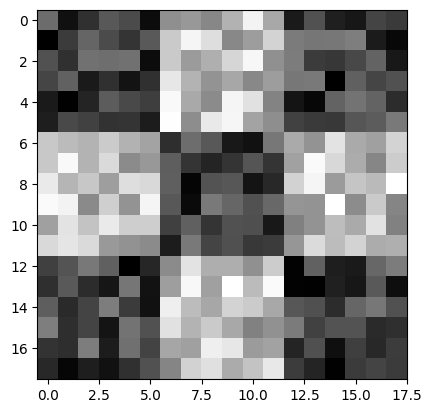

In [32]:
plt.imshow(
    np.random.randint(255, size=(18, 18))+cbimg,
    cmap="gray"
)